In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
filename = 'data/pross/data_tower.csv'
tower_df = pd.read_csv(filename, sep='\t')
# --- Preparación de datos e índices temporales ---
tower_df["datetime"] = pd.to_datetime(tower_df["datetime"])
tower_df = tower_df.set_index("datetime")
tower_df.columns

Index(['SUp', 'SDn', 'LUpCo', 'LDnCo', 'SHF', 'H', 'LE', 'Rn', 'SEB_Consumed',
       'SEB_Residual', 'tair', 'rh', 'press', 'wind_speed'],
      dtype='object')

In [8]:
filename = 'data/pross/data_buoy_full_time.csv'
bouy_df = pd.read_csv(filename, sep='\t')
bouy_df["datetime"] = pd.to_datetime(bouy_df["datetime"])
bouy_df = bouy_df.set_index("datetime")
bouy_df.columns

Index(['ws', 'tair', 'rh', 'press', 'SUp', 'sst', 'H', 'LE'], dtype='object')

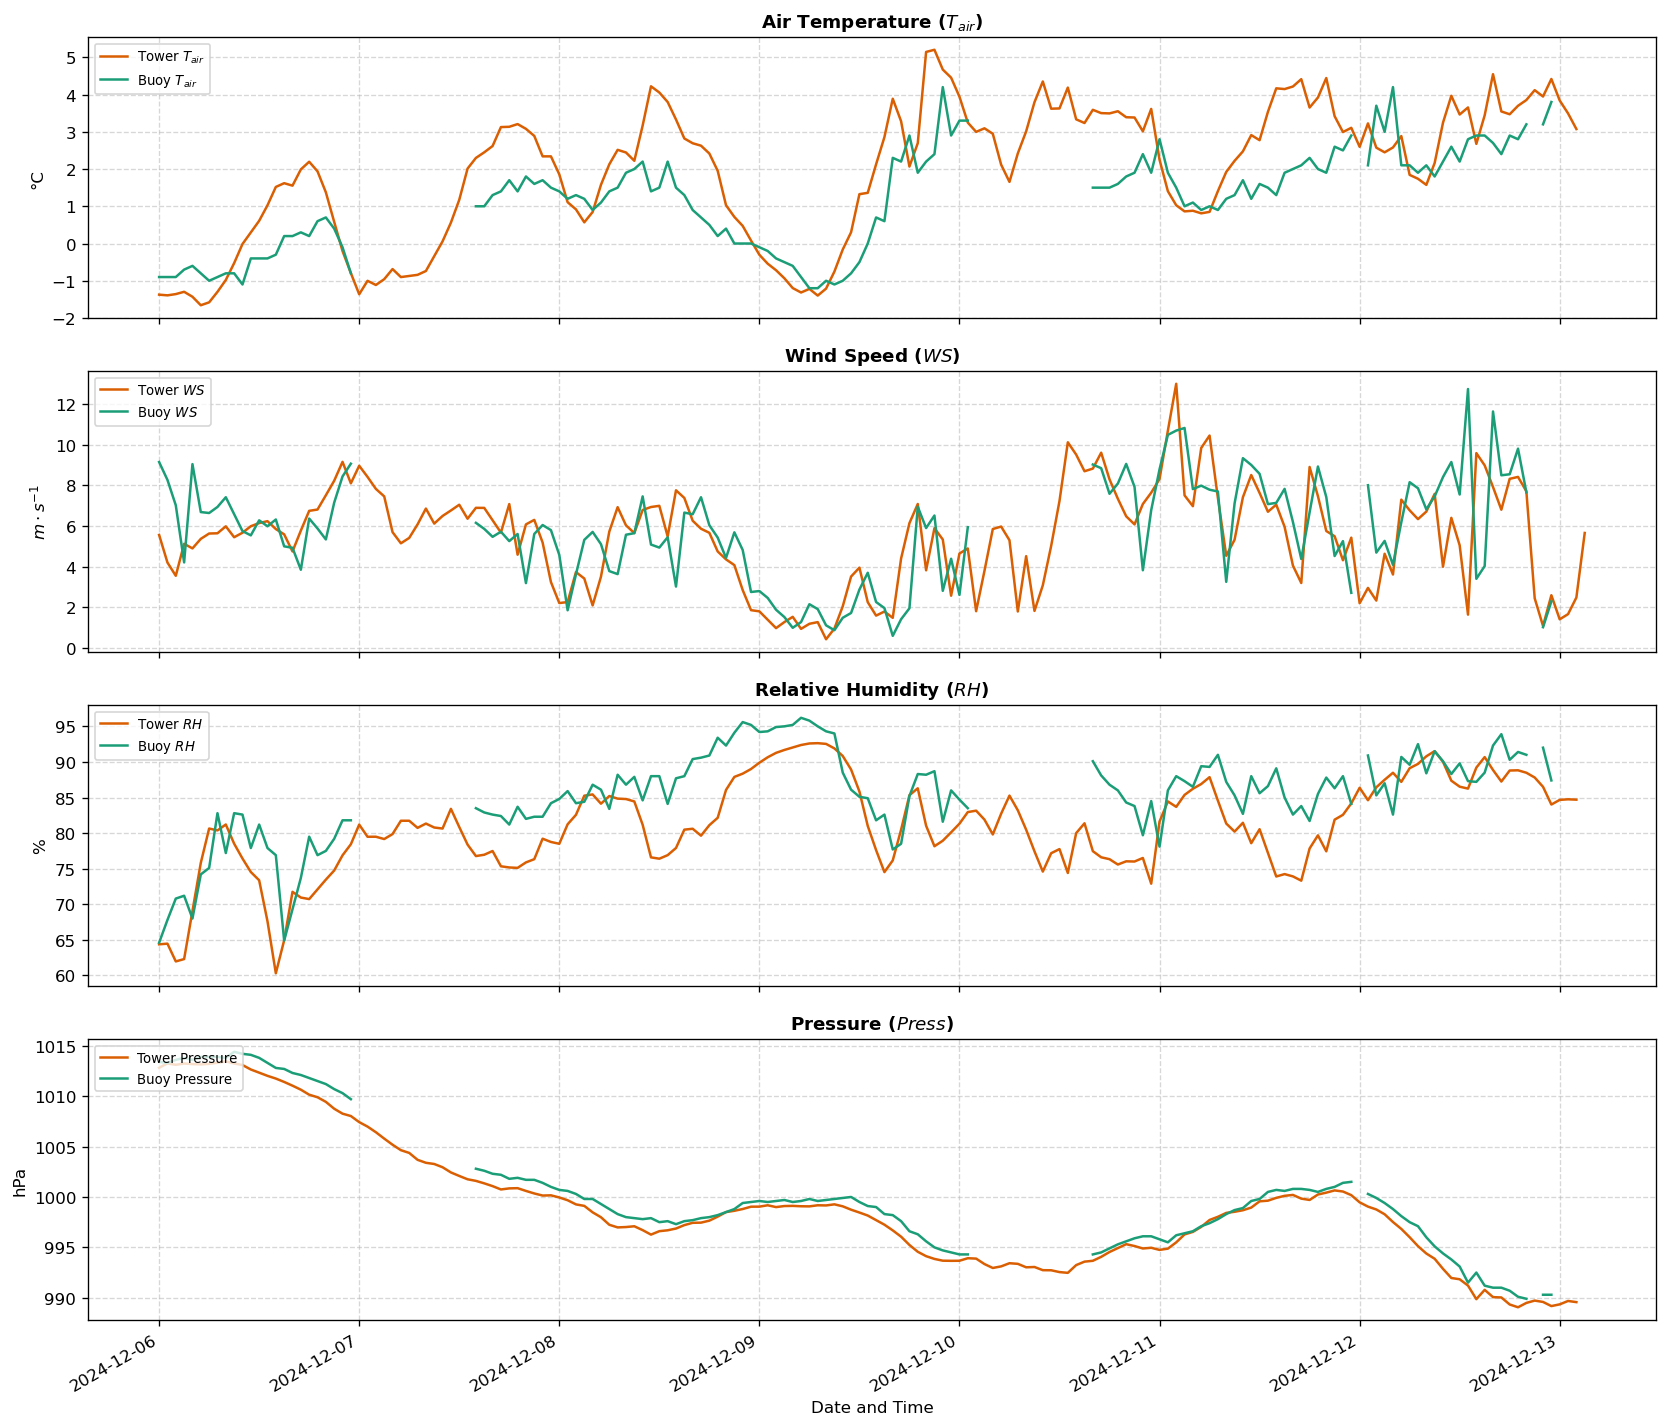

In [9]:
import matplotlib.pyplot as plt

# Definir colores consistentes
color_tower = "#d95f02"  # Naranja
color_buoy = "#1b9e77"   # Verde

# ==============================================================================
# FIGURA 1: Variables Meteorológicas (tair, ws, rh, press)
# ==============================================================================
fig1, (ax1, ax2, ax3, ax4) = plt.subplots(
    4, 1, figsize=(14, 12), sharex=True, dpi=120
)

# 1. Air Temperature (tair)
ax1.plot(
    tower_df.index,
    tower_df["tair"],
    label="Tower $T_{air}$",
    color=color_tower,
    linewidth=1.5,
)
ax1.plot(
    bouy_df.index,
    bouy_df["tair"],
    label="Buoy $T_{air}$",
    color=color_buoy,
    linewidth=1.5,
)
ax1.set_title("Air Temperature ($T_{air}$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("°C", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 2. Wind Speed (ws)
ax2.plot(
    tower_df.index,
    tower_df["wind_speed"],
    label="Tower $WS$",
    color=color_tower,
    linewidth=1.5,
)
ax2.plot(
    bouy_df.index,
    bouy_df["ws"],
    label="Buoy $WS$",
    color=color_buoy,
    linewidth=1.5,
)
ax2.set_title("Wind Speed ($WS$)", fontsize=11, fontweight="bold")
ax2.set_ylabel("$m \\cdot s^{-1}$", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 3. Relative Humidity (rh)
ax3.plot(
    tower_df.index,
    tower_df["rh"],
    label="Tower $RH$",
    color=color_tower,
    linewidth=1.5,
)
ax3.plot(
    bouy_df.index,
    bouy_df["rh"],
    label="Buoy $RH$",
    color=color_buoy,
    linewidth=1.5,
)
ax3.set_title("Relative Humidity ($RH$)", fontsize=11, fontweight="bold")
ax3.set_ylabel("%", fontsize=10)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 4. Pressure (press)
ax4.plot(
    tower_df.index,
    tower_df["press"],
    label="Tower Pressure",
    color=color_tower,
    linewidth=1.5,
)
ax4.plot(
    bouy_df.index,
    bouy_df["press"],
    label="Buoy Pressure",
    color=color_buoy,
    linewidth=1.5,
)
ax4.set_title("Pressure ($Press$)", fontsize=11, fontweight="bold")
ax4.set_xlabel("Date and Time", fontsize=10)
ax4.set_ylabel("hPa", fontsize=10)
ax4.grid(True, linestyle="--", alpha=0.5)
ax4.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

fig1.autofmt_xdate()
fig1.tight_layout()
plt.show()

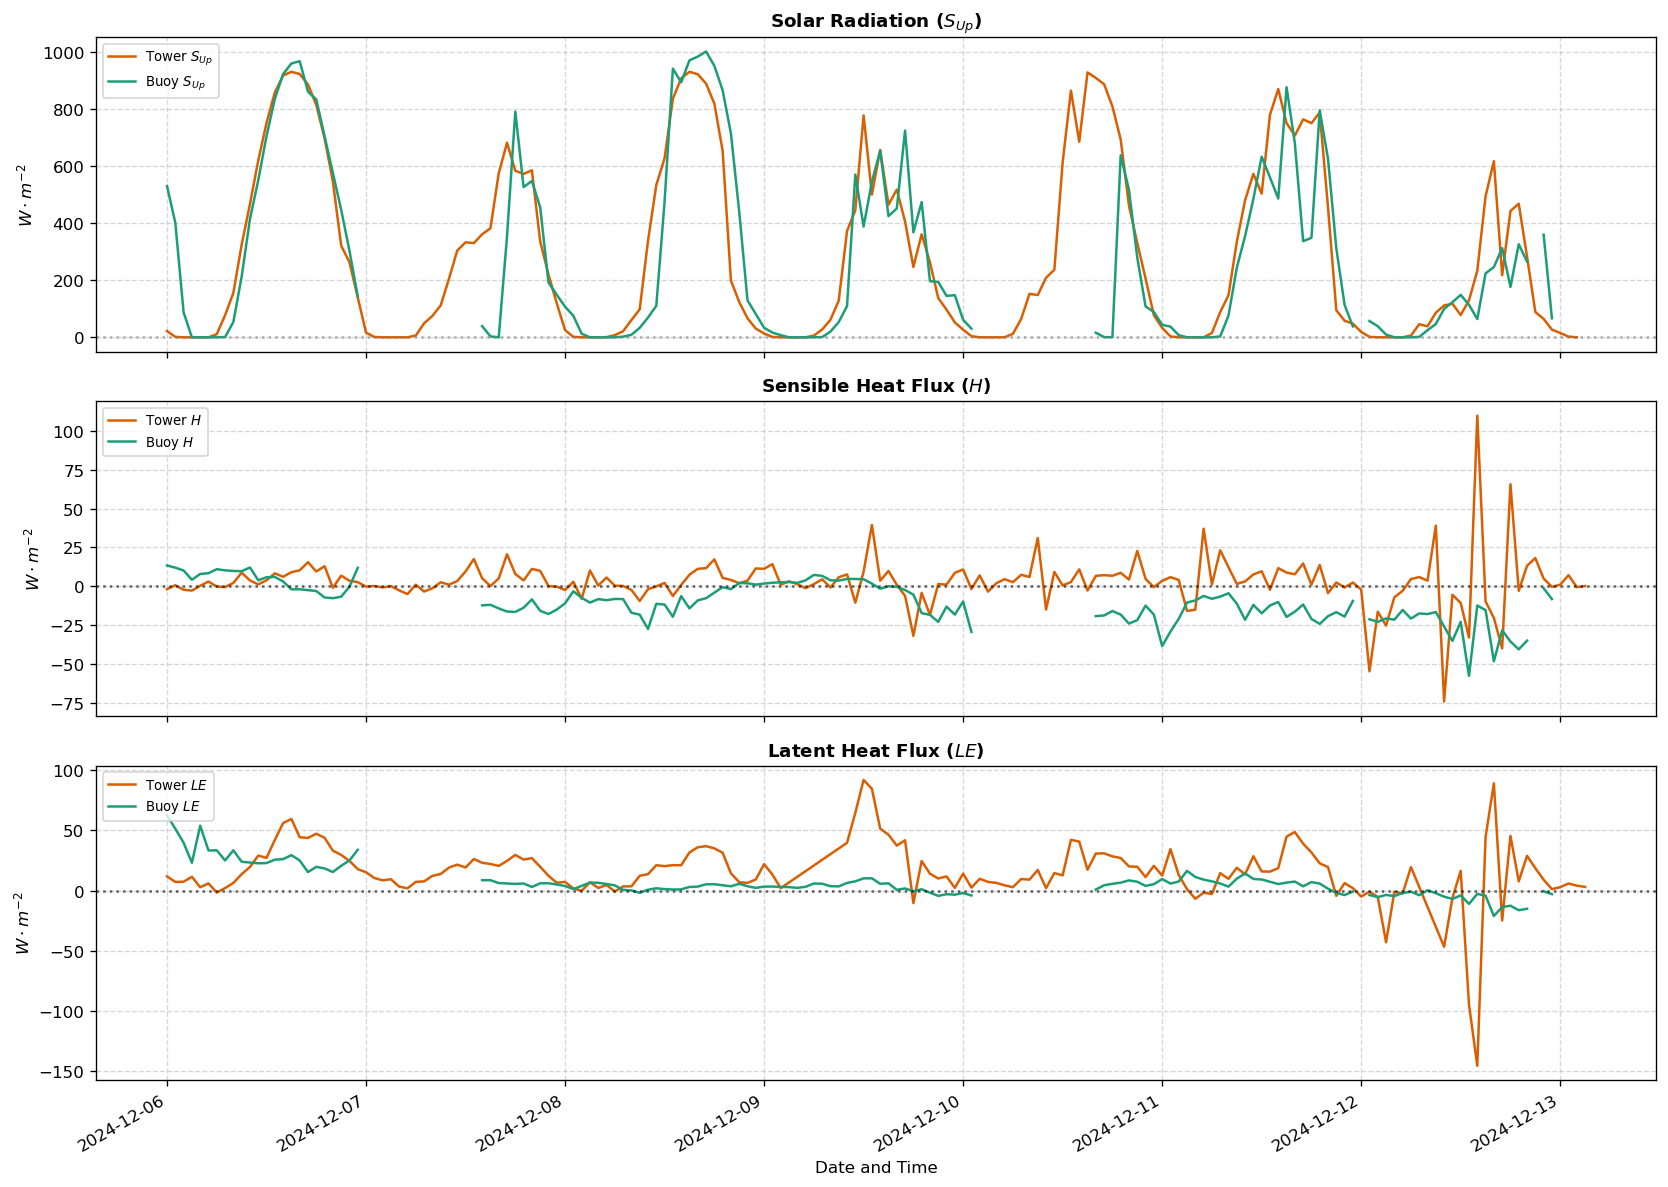

In [10]:
import matplotlib.pyplot as plt

# Definir los mismos colores consistentes
color_tower = "#d95f02"  # Naranja
color_buoy = "#1b9e77"  # Verde

# ==============================================================================
# FIGURA 2: Radiación Solar y Flujos Turbulentos (SUp, H, LE)
# ==============================================================================
fig2, (ax_sup, ax_h, ax_le) = plt.subplots(
    3, 1, figsize=(14, 10), sharex=True, dpi=120
)

# 1. Solar Radiation (SUp)
ax_sup.plot(
    tower_df.index,
    tower_df["SUp"],
    label="Tower $S_{Up}$",
    color=color_tower,
    linewidth=1.5,
)
ax_sup.plot(
    bouy_df.index,
    bouy_df["SUp"],
    label="Buoy $S_{Up}$",
    color=color_buoy,
    linewidth=1.5,
)
ax_sup.set_title("Solar Radiation ($S_{Up}$)", fontsize=11, fontweight="bold")
ax_sup.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_sup.axhline(0, color="gray", linestyle=":", alpha=0.6)
ax_sup.grid(True, linestyle="--", alpha=0.5)
ax_sup.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 2. Sensible Heat Flux (H)
ax_h.plot(
    tower_df.index,
    tower_df["H"],
    label="Tower $H$",
    color=color_tower,
    linewidth=1.5,
)
ax_h.plot(
    bouy_df.index,
    bouy_df["H"],
    label="Buoy $H$",
    color=color_buoy,
    linewidth=1.5,
)
ax_h.set_title("Sensible Heat Flux ($H$)", fontsize=11, fontweight="bold")
ax_h.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_h.axhline(0, color="black", linestyle=":", alpha=0.6)
ax_h.grid(True, linestyle="--", alpha=0.5)
ax_h.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

# 3. Latent Heat Flux (LE)
ax_le.plot(
    tower_df.index,
    tower_df["LE"],
    label="Tower $LE$",
    color=color_tower,
    linewidth=1.5,
)
ax_le.plot(
    bouy_df.index,
    bouy_df["LE"],
    label="Buoy $LE$",
    color=color_buoy,
    linewidth=1.5,
)
ax_le.set_title("Latent Heat Flux ($LE$)", fontsize=11, fontweight="bold")
ax_le.set_xlabel("Date and Time", fontsize=10)
ax_le.set_ylabel("$W \\cdot m^{-2}$", fontsize=10)
ax_le.axhline(0, color="black", linestyle=":", alpha=0.6)
ax_le.grid(True, linestyle="--", alpha=0.5)
ax_le.legend(loc="upper left", frameon=True, facecolor="white", fontsize=8)

fig2.autofmt_xdate()
fig2.tight_layout()
plt.show()